In [1]:
#Parameters

Scenario = None
T_planet = None
M_planet = None
R_planet = None
G_planet = None
Z_planet = None
Age = None

T_star = None
R_star = None
G_star = None
Z_star = None

folder_name = None

In [3]:
#import the libraries 
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy import fftpack,signal
from scipy import interpolate, special

import matplotlib
from matplotlib.ticker import ScalarFormatter
from astropy.visualization import (MinMaxInterval, SqrtStretch, ImageNormalize, ZScaleInterval)
import scipy
import json
import subprocess
import os
import emcee
import tqdm
import corner

from exocrires import spectra_2d
from exocrires import analysis
from exocrires import info

from astropy.io import fits
from astropy.table import Table


from exotic_ld import StellarLimbDarkening


from __future__ import print_function, division

from PyAstronomy import funcFit as fuf
from PyAstronomy import pyasl

import scipy.integrate as sci


path='/Users/richard/project_EXOCRIRES'
day='0308'

path_a='/Users/richard/project_EXOCRIRES/%s'%folder_name
lambda_range=info.lambda_range

## 1. Stellar Spectrum

### 1.1 Convolution with Gaussian Line Spread Function and Rotational Broadening Function

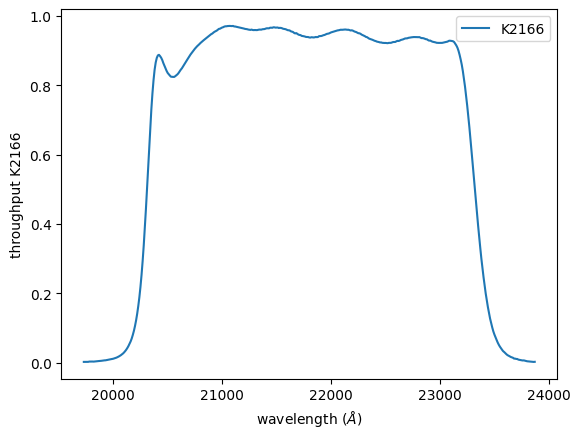

T, Z, G 4300 -0.0 3.5


limb darkening coefficient at K2166 band [0.467]


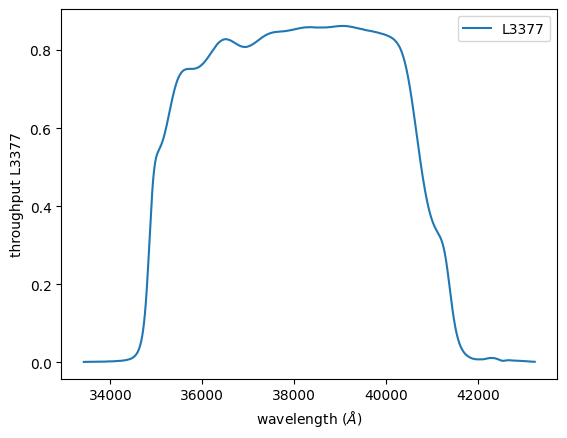

T, Z, G 4300 -0.0 3.5


limb darkening coefficient at L3377 band [0.3098]


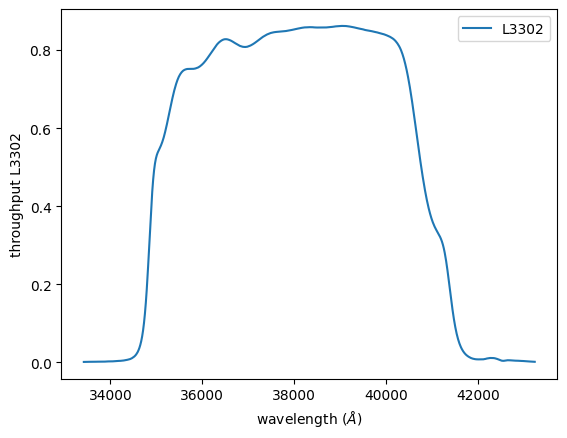

T, Z, G 4300 -0.0 3.5


limb darkening coefficient at L3302 band [0.3096]


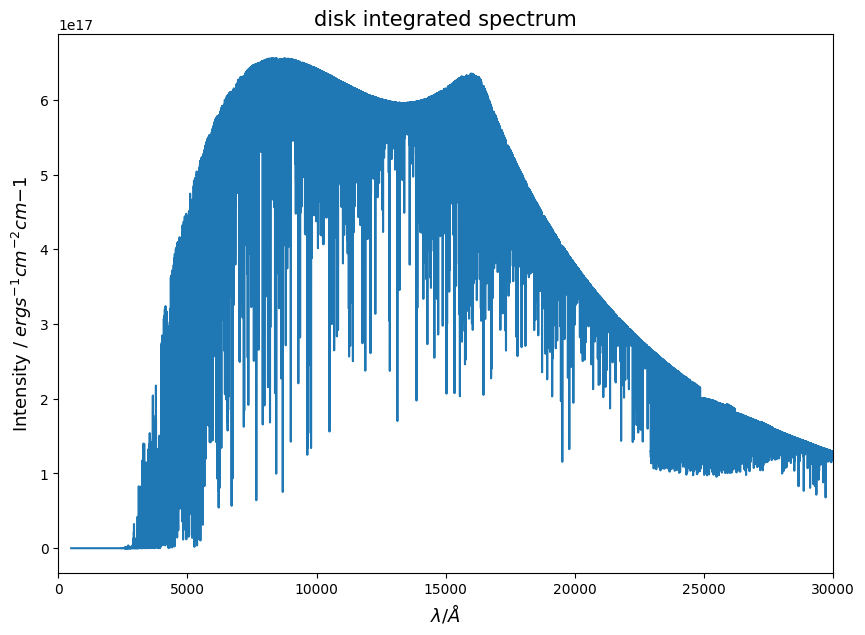

In [4]:
# Calvulate the limb darkening coefficients
# change the wavelength unit to angstrom 
# IMPORTANT: THE SPECTRUM NEEDS TO COVER BOTH K and L BAND SINCE NO BRIGHTNESS MEASUREMENT AT L BAND

# Calculate the limb darkening coefficients from K and L band

wavelength_range=info.lambda_range['wave']

def generate_synthetic_stellar_models(model_spec, n_mus, factor):
    # Generate I(lambda, mu).
    n_wvs = len(model_spec)
    mus = np.linspace(0, 1, n_mus)
    stellar_intensity = []

    for mu in mus:
        stellar_intensity.append(model_spec*factor)

    return mus, np.array(stellar_intensity).T


ld_coffecients = np.zeros((len(wavelength_range), 1))

for index in [-3,-2, -1]:
    
    wavelengths=[wavelength_range[index][0][0]*10, wavelength_range[index][-1][-1]*10]

    key = info.lambda_range['key'][index]

    if index in [-2, -1]:
        
        throughput=np.loadtxt(path+'/Paranal_ERIS_Lp.dat')
    
    else:
        throughput = np.loadtxt(path+'/SPHERE_IRDIS_B_%s.dat'%key[0])   

    wave_throughput=throughput[:,0]
    frac_throughput=throughput[:,1]

    plt.plot(wave_throughput,frac_throughput, label='%s'%key)
    plt.xlabel('wavelength ($\AA$)')
    plt.ylabel('throughput %s'%key)

    plt.legend()
    plt.show()

    print("T, Z, G", T_star, Z_star, G_star)

    sld=StellarLimbDarkening(ld_model='phoenix', ld_data_path='/Users/richard/project_EXOCRIRES/ld_data',\
                             M_H=Z_star, Teff=T_star, logg=G_star)
    
    cs=sld.compute_linear_ld_coeffs(mode='custom', wavelength_range=wavelengths, custom_wavelengths=wave_throughput, custom_throughput=frac_throughput)

    print("limb darkening coefficient at %s band"%key, np.float16(cs))

    ld_coffecients[index] = np.float16(cs)

rs = (1 - sld.mus**2)**0.5
roots, weights = special.roots_legendre(500)
a, b = (0., 1.)
t = (b - a) / 2 * roots + (a + b) / 2

spectrum = []
for wv_idx in range(sld.stellar_wavelengths.shape[0]):

    i_interp_func = interpolate.interp1d(
        rs, sld.stellar_intensities[wv_idx, :], kind='linear',
        bounds_error=False, fill_value=0.)

    def integrand(_r):
        return i_interp_func(_r) * _r * 2. * np.pi

    spectrum.append((b - a) / 2. * integrand(t).dot(weights))

plt.figure(figsize=(10, 7))
plt.plot(sld.stellar_wavelengths, spectrum)
plt.xlabel("$\lambda / \AA$", fontsize=13)
plt.ylabel("Intensity / $erg s^{-1} cm^{-2} cm {-1}$", fontsize=13)
plt.xlim(0, 3e4)

plt.title('disk integrated spectrum', fontsize=15)
plt.show()

resolution of the input spectrum: 798959.2265859017
delta_lam: 0.03473252961678692
Sample grid is not equal. Use pyasl.equidistantInterpolation to produce equidistantly sampled data. 
----Convolution with LSF and rotational broadening kernel starts----


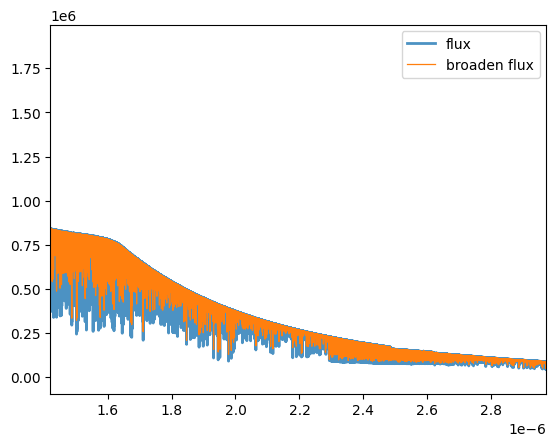

In [5]:
#Calculate the broadened spectrum
#Convolve a LSF
import scipy.ndimage

flux=fits.open(path_a+'/lte0%s-%s0%s.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits'%(T_star,G_star,Z_star))
flux=flux[0].data
wave=fits.open(path_a+'/WAVE_PHOENIX-ACES-AGSS-COND-2011.fits')
wave=wave[0].data

 

def gaussian_broaden_spectrum(wavelength, flux, R):
    # Convert wavelength to log space
    log_wavelength = np.log(wavelength)
    
    # Define FWHM and standard deviation in log space
    fwhm_log = 1 / R
    sigma_log = fwhm_log / 2.355  # Convert FWHM to sigma
    
    # Convolve the flux with a Gaussian kernel in log space
    broadened_flux = scipy.ndimage.gaussian_filter1d(flux, sigma=sigma_log / (log_wavelength[1] - log_wavelength[0]))
    
    return broadened_flux

def resolution_sample(ave_R, wavelength):
    
    lam_range=np.max(wavelength)-np.min(wavelength)
    
    lam_mid=(np.max(wavelength)+np.min(wavelength))/2
    
    N=ave_R*(lam_range/lam_mid)+1
    
    return (int(N))

# Example: wavelengths, fluxes, and resolution R
N_sample=len(wave)
lam_range=np.max(wave)-np.min(wave)
lam_mid=(np.max(wave)+np.min(wave))/2
R_sample =  (N_sample-1)/(lam_range/lam_mid)
print('resolution of the input spectrum:', R_sample)

delta_lam=lam_mid/R_sample
print("delta_lam:", delta_lam)

### Use pyasl.equidistantInterpolation to produce equidistantly sampled data

if (wave[1]-wave[0]) != (wave[-1]-wave[-2]):

    print ('Sample grid is not equal. Use pyasl.equidistantInterpolation to produce equidistantly sampled data. ')

    step_size=1e-1
    new_wave, new_flux = pyasl.equidistantInterpolation(wave, flux, step_size)

else:
    new_wave=wave
    new_flux=flux

R=1e5
reu=500 #redundant in nm


# Broaden the spectrum at separate bands and then reduce the size
new_wave*=1e-10 #m
new_flux*=1e-8  #erg/s/cm2/A

print ('----Convolution with LSF and rotational broadening kernel starts----')
for i in range(len(info.lambda_range['wave']))[-3:-2]:

    ld_coefficient=ld_coffecients[i][0]
    rotation=5 #km/s, https://ui.adsabs.harvard.edu/abs/2006yCat..34630671R/abstract

    lam=info.lambda_range['wave'][i]

    mask=np.array((new_wave>=(lam[0][0]-reu)*1e-9) & (new_wave <=(lam[-1][-1]+reu)*1e-9))

    lb_coeff=np.float16(ld_coefficient)
    rflux=pyasl.fastRotBroad(wvl=new_wave[mask], flux=new_flux[mask], epsilon=ld_coefficient, vsini=rotation)
    broadened_flux = gaussian_broaden_spectrum(new_wave[mask], rflux, R)

    plt.plot(new_wave, new_flux, label='flux', alpha=0.8, linewidth=2)
    plt.plot(new_wave[mask], broadened_flux, label='broaden flux', linewidth=0.9)
    plt.xlim(new_wave[mask][0], new_wave[mask][-1])
    #plt.ylim(0,1e10)
    #plt.yscale('log')
    
    plt.legend()
    plt.show()

    #----------

    N=resolution_sample(R*2, new_wave[mask])

    wave_grid=np.linspace(np.min(new_wave[mask]), np.max(new_wave[mask]), N)

    inter_flux=np.interp(wave_grid, new_wave[mask], broadened_flux)

    spec_lowres=np.array([wave_grid, inter_flux]).T
    np.savetxt(path_a+'/spectra_input/upload_star_lowres_%s_rot_lsf.dat'%info.lambda_range['key'][i], spec_lowres)

### 1.2 Velocity Injection

In [6]:
#everything here in SI units

for v in np.arange(-50, 50, 1): #km/s

    for i in range(len(info.lambda_range['wave']))[-3:-2]:
    
        data= np.loadtxt(path_a+'/spectra_input/upload_star_lowres_%s_rot_lsf.dat'%info.lambda_range['key'][i])
        wavelengths=data[:,0]
        flux=data[:,1]

        wavelengths_shift= wavelengths*(1+(v*1e3/scipy.constants.c))
        spec_shift=np.array([wavelengths_shift, flux]).T
        '''
        plt.plot(wavelengths, flux)
        plt.plot(wavelengths_shift, flux, label='shiftted spectrum')

        plt.xlim(wavelengths[1000], wavelengths[1000+50])
        plt.legend()
        plt.show()
        '''
        np.savetxt(path_a+'/spectra_input/upload_star_lowres_%s_rot_lsf_%skm.dat'%(info.lambda_range['key'][i],v), spec_shift)

### 1.3 Brightness calculation

In [7]:
pc = 3.086e18 #cm

r_sun =  6.96e10 # solar radius in cm

Luminosity_sun = 3.828e33  # Solar luminosity in erg/s

Luminoisty_jup = 3.3e24  #Jupiter luminosity in erg/s

k_band_wave=np.array(info.lambda_range['wave'][-3])

#flux_K=np.load(path_a+'/f_pRT_Kband_t1700_g31nc_m0.0.npy')
#wave_K=np.load(path_a+'/wave_pRT_Kband.npy')*1e-6

spec_star=np.loadtxt(path_a+'/spectra_input/upload_star_lowres_K2166_rot_lsf_10km.dat').T
#spec_planet=np.array([wave_K, flux_K])

brightness_caculator = analysis.planet_para(data_planet=spec_star)

r_star = R_star*r_sun


throughput = np.loadtxt(path+'/SPHERE_IRDIS_B_K.dat')
throughput[:,0] = throughput[:,0]*1e-10 #m
mag_K=brightness_caculator.mag_direct(radius=r_star, distance=140*pc, solid_angle=4*np.pi, band=k_band_wave*1e-9, transmission=throughput.T, zero=4.08361e-11)
print('magnitude in K band:', mag_K[0], mag_K[1], mag_K[2])

simulation_parameters = pd.read_csv(path+'/simulation_log.csv')
simulation_parameters.loc[simulation_parameters['Age']==Age, 'Mag_star_K'] = mag_K[0]


wavelength range: 1.9214730478877637e-06 2.4724107093707057e-06
magnitude in K band: 8.141632878139808 271056.5859008687 0.0005537922181088233


## 2. Planet Photosphere Spectrum (pRT)

### 2.1 Convolution

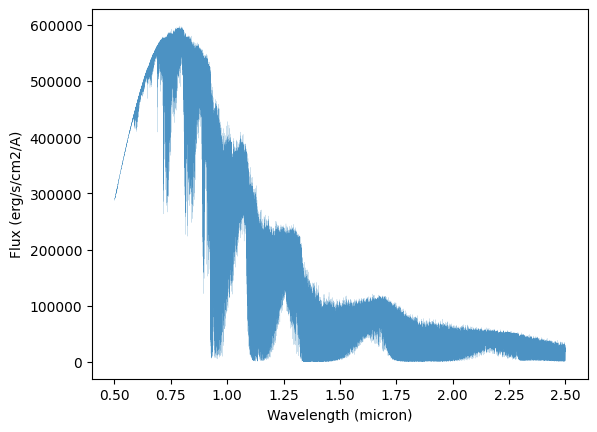

In [8]:
#Convert Lorenzo Spectra
#plot the forward model with T = 1700K

factor=1e-8

#flux_L=np.load(path_a+'/f_pRT_Kband_t1600_g100nc_m0.0.npy')
#wave_L=np.load(path_a+'/wave_pRT_Kband.npy')

G_p_m = int(10**(G_planet-2))

flux_K=np.load(path_a+'/f_pRT_t%s_g%snc_m0.0.npy'%(T_planet, G_p_m))
wave_K=np.load(path+'/wave_pRT.npy')

#plt.plot(wave_L, flux_L*factor, linewidth=0.1, alpha=0.8)


#plt.xlabel('Wavelength (micron)')
#plt.ylabel('Flux (erg/s/cm2/A)')

#plt.show()

plt.plot(wave_K, flux_K*factor, linewidth=0.1, alpha=0.8)

plt.xlabel('Wavelength (micron)')
plt.ylabel('Flux (erg/s/cm2/A)')
#plt.xlim(1.9, 2.2)
#plt.ylim(0, 4e-5)
plt.show()

#print (wave_L.min(), wave_L.max())

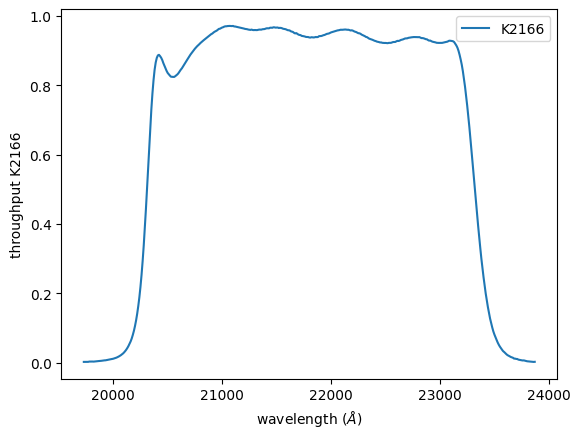

/Users/richard/opt/anaconda3/lib/python3.9/site-packages/exotic_ld/ld_computation.py:650: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(ld_law_func,


limb darkening coefficient at K2166 band [-0.]


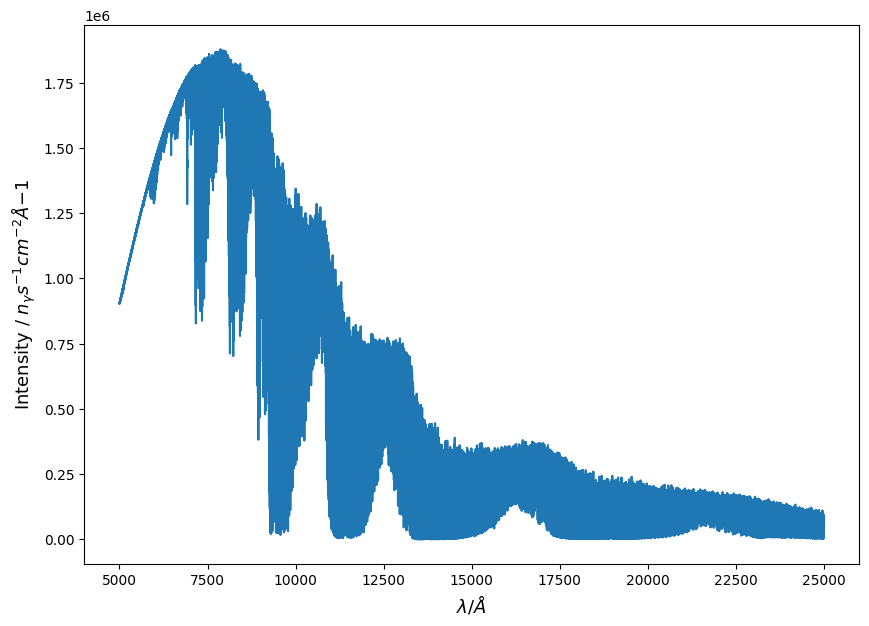

In [9]:
ld_coffecients = np.zeros((len(wavelength_range), 1))
for index in [-3]:

    wave=np.load(path+'/wave_pRT.npy')
    flux=np.load(path_a+'/f_pRT_t%s_g%snc_m0.0.npy'%(T_planet, G_p_m))

    planet_mus, planet_intensities = generate_synthetic_stellar_models(flux, 70, factor=1e-8)
    
    wavelengths=[wavelength_range[index][0][0]*10, wavelength_range[index][-1][-1]*10]

    key = info.lambda_range['key'][index]

    if index in [-2,-1]:
        
        throughput=np.loadtxt(path+'/Paranal_ERIS_Lp.dat')
    
    else:
         throughput = np.loadtxt(path+'/SPHERE_IRDIS_B_%s.dat'%key[0])

    wave_throughput=throughput[:,0]
    frac_throughput=throughput[:,1]

    plt.plot(wave_throughput,frac_throughput, label='%s'%key)
    plt.xlabel('wavelength ($\AA$)')
    plt.ylabel('throughput %s'%key)

    plt.legend()
    plt.show()


    sld=StellarLimbDarkening(ld_model='custom', ld_data_path='/Users/richard/project_EXOCRIRES/ld_data', \
        custom_wavelengths=wave*1e4, custom_stellar_model=planet_intensities, custom_mus=planet_mus)
    
    cs=sld.compute_linear_ld_coeffs(mode='custom', wavelength_range=wavelengths,   custom_wavelengths=wave_throughput, custom_throughput=frac_throughput)

    print("limb darkening coefficient at %s band"%key, np.float16(cs))

    ld_coffecients[index] = np.float16(cs)

rs = (1 - planet_mus**2)**0.5
roots, weights = special.roots_legendre(500)
a, b = (0., 1.)
t = (b - a) / 2 * roots + (a + b) / 2

spectrum = []
for wv_idx in range(planet_intensities.shape[0]):

    i_interp_func = interpolate.interp1d(
        rs, planet_intensities[wv_idx, :], kind='linear',
        bounds_error=False, fill_value=0.)

    def integrand(_r):
        return i_interp_func(_r) * _r * 2. * np.pi

    spectrum.append((b - a) / 2. * integrand(t).dot(weights))

plt.figure(figsize=(10, 7))
plt.plot(wave*1e4, spectrum)
plt.xlabel("$\lambda / \AA$", fontsize=13)
plt.ylabel("Intensity / $n_{\gamma} s^{-1} cm^{-2} \AA{-1}$", fontsize=13)
#plt.xlim(0, 3e4)
plt.show()

1207078.7030402464
1.24266980816755e-06
Sample grid is not equal. Use pyasl.equidistantInterpolation to produce equidistantly sampled data. 


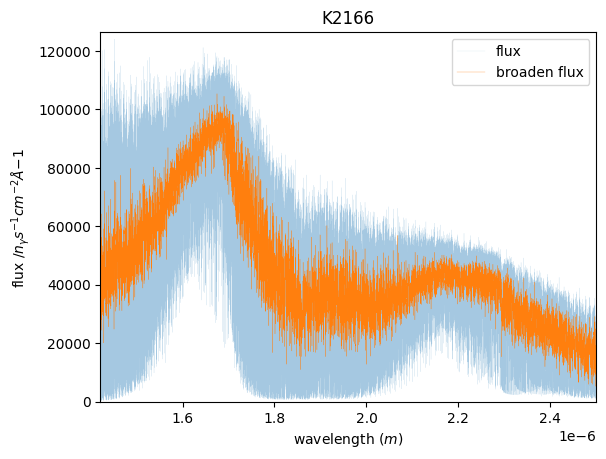

1207078.7030402464
1.24266980816755e-06
Sample grid is not equal. Use pyasl.equidistantInterpolation to produce equidistantly sampled data. 


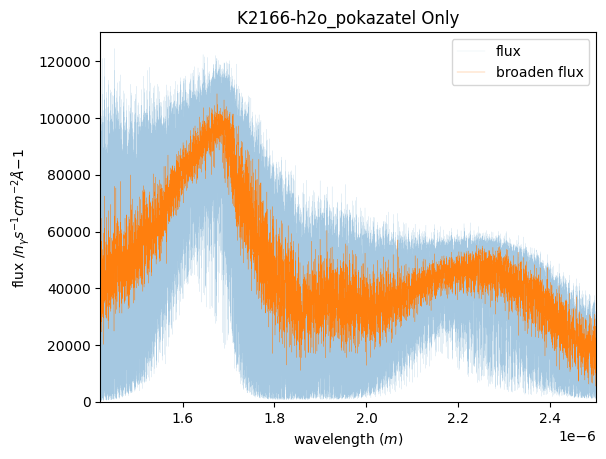

1207078.7030402464
1.24266980816755e-06
Sample grid is not equal. Use pyasl.equidistantInterpolation to produce equidistantly sampled data. 


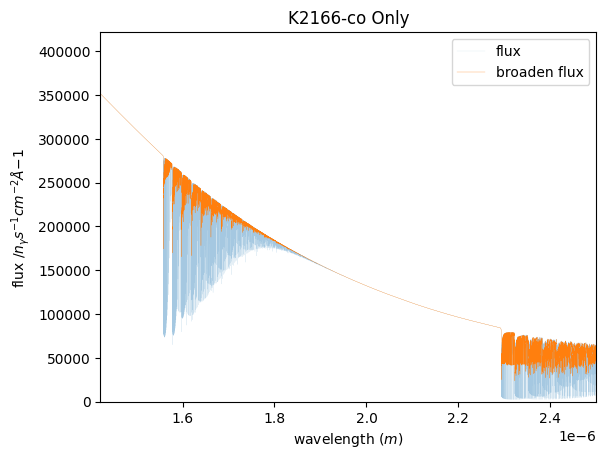

1207078.7030402464
1.24266980816755e-06
Sample grid is not equal. Use pyasl.equidistantInterpolation to produce equidistantly sampled data. 


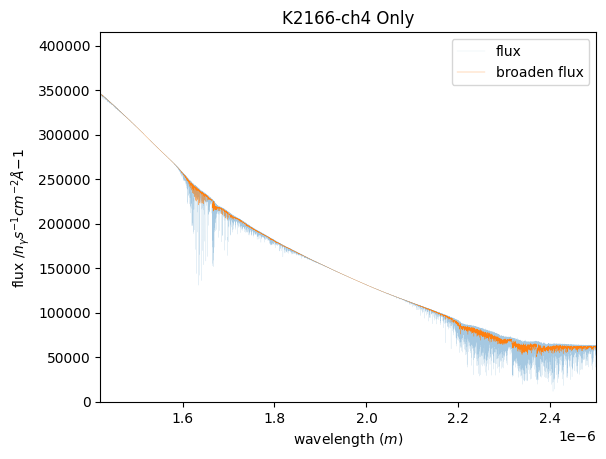

1207078.7030402464
1.24266980816755e-06
Sample grid is not equal. Use pyasl.equidistantInterpolation to produce equidistantly sampled data. 


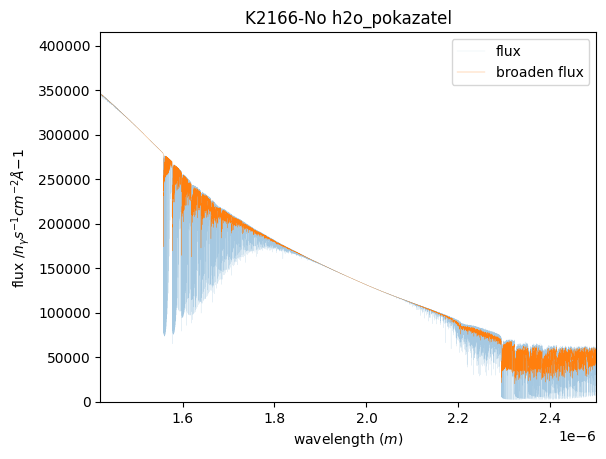

1207078.7030402464
1.24266980816755e-06
Sample grid is not equal. Use pyasl.equidistantInterpolation to produce equidistantly sampled data. 


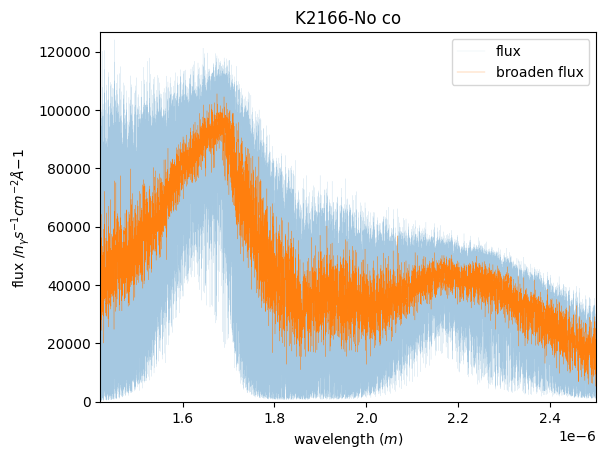

1207078.7030402464
1.24266980816755e-06
Sample grid is not equal. Use pyasl.equidistantInterpolation to produce equidistantly sampled data. 


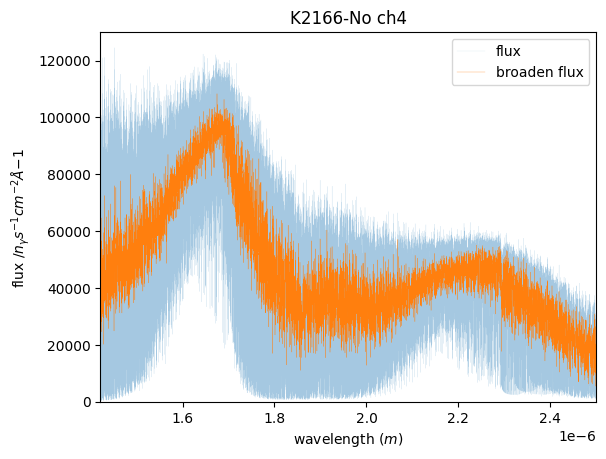

In [ ]:
#Convolve a the LSF and the rotational broadening kernel
import scipy.ndimage


vsini_planet=20 #km/s

def gaussian_broaden_spectrum(wavelength, flux, R):
    # Convert wavelength to log space
    log_wavelength = np.log(wavelength)
    
    # Define FWHM and standard deviation in log space
    fwhm_log = 1 / R
    sigma_log = fwhm_log / 2.355  # Convert FWHM to sigma
    
    # Convolve the flux with a Gaussian kernel in log space
    broadened_flux = scipy.ndimage.gaussian_filter1d(flux, sigma=sigma_log / (log_wavelength[1] - log_wavelength[0]))
    
    return broadened_flux

def resolution_sample(ave_R, wavelength):
    
    lam_range=np.max(wavelength)-np.min(wavelength)
    
    lam_mid=(np.max(wavelength)+np.min(wavelength))/2
    
    N=ave_R*(lam_range/lam_mid)+1
    
    return (int(N))

G_convert = int(10**(G_planet-2))

for index in [-3]:
    
    wave = np.load (path+'/wave_pRT.npy')
    flux = np.load (path_a+'/f_pRT_t%s_g%snc_m0.0.npy'%(T_planet, G_convert))
    ld_coffecient = ld_coffecients[index][0]

    # Example: wavelengths, fluxes, and resolution R
    N_sample=len(wave)
    lam_range=np.max(wave)-np.min(wave)
    lam_mid=(np.max(wave)+np.min(wave))/2
    R_sample =  (N_sample-1)/(lam_range/lam_mid)
    print(R_sample)

    delta_lam=lam_mid/R_sample
    print(delta_lam)

    ### Use pyasl.equidistantInterpolation to produce equidistantly sampled data

    if (wave[1]-wave[0]) != (wave[-1]-wave[-2]):

        print ('Sample grid is not equal. Use pyasl.equidistantInterpolation to produce equidistantly sampled data. ')

        step_size=1e-6
        new_wave, new_flux = pyasl.equidistantInterpolation(wave, flux, step_size)
    else:

        new_wave=wave
        new_flux=flux

    R=1e5
    reu=500 #redundant in nm


    # Broaden the spectrum at separate bands and then reduce the size
    new_wave*=1e-6 #m
    new_flux*=1e-8 # erg/s/cm2/A


    lam=info.lambda_range['wave'][index]
    key=info.lambda_range['key'][index]

    mask=np.array((new_wave>=(lam[0][0]-reu)*1e-9) & (new_wave <=(lam[-1][-1]+reu)*1e-9))


    rflux=pyasl.fastRotBroad(wvl=new_wave[mask], flux=new_flux[mask], epsilon=ld_coffecient, vsini=vsini_planet)
    broadened_flux = gaussian_broaden_spectrum(new_wave[mask], rflux, R)

    plt.plot(wave*1e-6, flux*1e-8, label='flux', alpha=0.4, linewidth=0.1)
    plt.plot(new_wave[mask], broadened_flux, label='broaden flux', linewidth=0.2)
    plt.xlim(new_wave[mask][0], new_wave[mask][-1])
    plt.ylim(0,np.max(broadened_flux)*1.2)

    plt.xlabel('wavelength ($m$)')
    plt.ylabel('flux /$n_{\gamma} s^{-1} cm^{-2} \AA{-1}$ ')

    plt.title ('%s'%key)
    
    plt.legend()
    plt.show()

    #----------

    N=resolution_sample(R*2, new_wave[mask])

    wave_grid=np.linspace(np.min(new_wave[mask]), np.max(new_wave[mask]), N)

    inter_flux=np.interp(wave_grid, new_wave[mask], broadened_flux)

    spec_lowres=np.array([wave_grid, inter_flux]).T
    np.savetxt(path_a+'/spectra_input/upload_lowres_%s_rot_lsf.dat'%info.lambda_range['key'][index], spec_lowres)

    #Same process for the molecular spectra 

    for mol in ['h2o_pokazatel', 'co', 'ch4']:

        flux=np.load(path_a+'/f_pRT_%s_only_t%s_g%snc_m0.0.npy'%(mol, T_planet, G_convert))
        wave=np.load(path+'/wave_pRT.npy')

        # Example: wavelengths, fluxes, and resolution R
        N_sample=len(wave)
        lam_range=np.max(wave)-np.min(wave)
        lam_mid=(np.max(wave)+np.min(wave))/2
        R_sample =  (N_sample-1)/(lam_range/lam_mid)
        print(R_sample)

        delta_lam=lam_mid/R_sample
        print(delta_lam)

        ### Use pyasl.equidistantInterpolation to produce equidistantly sampled data

        if (wave[1]-wave[0]) != (wave[-1]-wave[-2]):

            print ('Sample grid is not equal. Use pyasl.equidistantInterpolation to produce equidistantly sampled data. ')

            step_size=1e-6
            new_wave, new_flux = pyasl.equidistantInterpolation(wave, flux, step_size)
        else:

            new_wave=wave
            new_flux=flux

        R=1e5
        reu=500 #redundant in nm


        # Broaden the spectrum at separate bands and then reduce the size
        new_wave*=1e-6 #m
        new_flux*=1e-8 # erg/s/cm2/A


        lam=info.lambda_range['wave'][index]
        key=info.lambda_range['key'][index]

        mask=np.array((new_wave>=(lam[0][0]-reu)*1e-9) & (new_wave <=(lam[-1][-1]+reu)*1e-9))

        rflux=pyasl.fastRotBroad(wvl=new_wave[mask], flux=new_flux[mask], epsilon=ld_coffecient, vsini=vsini_planet)
        broadened_flux = gaussian_broaden_spectrum(new_wave[mask], rflux, R)

        plt.plot(wave*1e-6, flux*1e-8, label='flux', alpha=0.4, linewidth=0.1)
        plt.plot(new_wave[mask], broadened_flux, label='broaden flux', linewidth=0.2)
        plt.xlim(new_wave[mask][0], new_wave[mask][-1])
        plt.ylim(0,np.max(broadened_flux)*1.2)

        plt.xlabel('wavelength ($m$)')
        plt.ylabel('flux /$n_{\gamma} s^{-1} cm^{-2} \AA{-1}$ ')

        plt.title ('%s-%s Only'%(key,mol))
        
        plt.legend()
        plt.show()

        #----------

        N=resolution_sample(R*2, new_wave[mask])

        wave_grid=np.linspace(np.min(new_wave[mask]), np.max(new_wave[mask]), N)

        inter_flux=np.interp(wave_grid, new_wave[mask], broadened_flux)

        spec_lowres=np.array([wave_grid, inter_flux]).T
        np.savetxt(path_a+'/spectra_input/upload_lowres_%s_rot_lsf_%s_only.dat'%(info.lambda_range['key'][index],mol), spec_lowres)

    for mol in ['h2o_pokazatel', 'co', 'ch4']:

        flux=np.load(path_a+'/f_pRT_no_%s_t%s_g%snc_m0.0.npy'%(mol, T_planet, G_convert))
        wave=np.load(path+'/wave_pRT.npy')

        # Example: wavelengths, fluxes, and resolution R
        N_sample=len(wave)
        lam_range=np.max(wave)-np.min(wave)
        lam_mid=(np.max(wave)+np.min(wave))/2
        R_sample =  (N_sample-1)/(lam_range/lam_mid)
        print(R_sample)

        delta_lam=lam_mid/R_sample
        print(delta_lam)

        ### Use pyasl.equidistantInterpolation to produce equidistantly sampled data

        if (wave[1]-wave[0]) != (wave[-1]-wave[-2]):

            print ('Sample grid is not equal. Use pyasl.equidistantInterpolation to produce equidistantly sampled data. ')

            step_size=1e-6
            new_wave, new_flux = pyasl.equidistantInterpolation(wave, flux, step_size)
        else:

            new_wave=wave
            new_flux=flux

        R=1e5
        reu=500 #redundant in nm


        # Broaden the spectrum at separate bands and then reduce the size
        new_wave*=1e-6 #m
        new_flux*=1e-8 # erg/s/cm2/A


        lam=info.lambda_range['wave'][index]
        key=info.lambda_range['key'][index]

        mask=np.array((new_wave>=(lam[0][0]-reu)*1e-9) & (new_wave <=(lam[-1][-1]+reu)*1e-9))

        rflux=pyasl.fastRotBroad(wvl=new_wave[mask], flux=new_flux[mask], epsilon=ld_coffecient, vsini=vsini_planet)
        broadened_flux = gaussian_broaden_spectrum(new_wave[mask], rflux, R)

        plt.plot(wave*1e-6, flux*1e-8, label='flux', alpha=0.4, linewidth=0.1)
        plt.plot(new_wave[mask], broadened_flux, label='broaden flux', linewidth=0.2)
        plt.xlim(new_wave[mask][0], new_wave[mask][-1])
        plt.ylim(0,np.max(broadened_flux)*1.2)

        plt.xlabel('wavelength ($m$)')
        plt.ylabel('flux /$n_{\gamma} s^{-1} cm^{-2} \AA{-1}$ ')

        plt.title ('%s-No %s'%(key,mol))
        
        plt.legend()
        plt.show()

        #----------

        N=resolution_sample(R*2, new_wave[mask])

        wave_grid=np.linspace(np.min(new_wave[mask]), np.max(new_wave[mask]), N)

        inter_flux=np.interp(wave_grid, new_wave[mask], broadened_flux)

        spec_lowres=np.array([wave_grid, inter_flux]).T
        np.savetxt(path_a+'/spectra_input/upload_lowres_%s_rot_lsf_no_%s.dat'%(info.lambda_range['key'][index],mol), spec_lowres)

### 2.2 Velocity Injection

In [11]:
#everything here in SI units

for v in np.arange(-100, 100, 1): #km/s

    for i in range(len(info.lambda_range['wave']))[-3:-2]:
    
        data= np.loadtxt(path_a+'/spectra_input/upload_lowres_%s_rot_lsf.dat'%info.lambda_range['key'][i])
        wavelengths=data[:,0]
        flux=data[:,1]

        wavelengths_shift= wavelengths*(1+(v*1e3/scipy.constants.c))
        spec_shift=np.array([wavelengths_shift, flux]).T

        np.savetxt(path_a+'/spectra_input/upload_lowres_%s_rot_lsf_%skm.dat'%(info.lambda_range['key'][i],v), spec_shift)


        for mol in ['h2o_pokazatel', 'co', 'ch4']:

            data= np.loadtxt(path_a+'/spectra_input/upload_lowres_%s_rot_lsf_no_%s.dat'%(info.lambda_range['key'][i],mol))
            wavelengths=data[:,0]
            flux=data[:,1]

            wavelengths_shift= wavelengths*(1+(v*1e3/scipy.constants.c))
            spec_shift=np.array([wavelengths_shift, flux]).T

            np.savetxt(path_a+'/spectra_input/upload_lowres_%s_rot_lsf_no_%s_%skm.dat'%(info.lambda_range['key'][i],mol,v), spec_shift)

data=np.loadtxt(path_a+'/spectra_input/upload_lowres_K2166_rot_lsf_-50km.dat')
wave=data[:,0]
flux=data[:,1]

print(wave.min(), wave.max())

1.4212315582336451e-06 2.4995836784892924e-06


### 2.3 Brightness calculation

In [12]:
pc = 3.086e18 #cm

r_jup = 7.1492e9  # Jupiter radius in cm

Luminosity_sun = 3.828e33  # Solar luminosity in erg/s

Luminoisty_jup = 3.3e24  #Jupiter luminosity in erg/s

k_band_wave=np.array(info.lambda_range['wave'][-3])

#flux_K=np.load(path_a+'/f_pRT_Kband_t1700_g31nc_m0.0.npy')
#wave_K=np.load(path_a+'/wave_pRT_Kband.npy')*1e-6

spec_planet=np.loadtxt(path_a+'/spectra_input/upload_lowres_K2166_rot_lsf_10km.dat').T
#spec_planet=np.array([wave_K, flux_K])

brightness_caculator = analysis.planet_para(data_planet=spec_planet)

r_planet = R_planet*r_jup
mag_K=brightness_caculator.mag_direct(radius=r_planet, distance=140*pc, solid_angle=4*np.pi, band=k_band_wave*1e-9, transmission=throughput.T, zero=4.08361e-11)
print('magnitude in K band:', mag_K[0], mag_K[1], mag_K[2])  

simulation_parameters.loc[simulation_parameters['Age']==Age, 'Mag_planet_K'] = mag_K[0]

wavelength range: 1.921471271659315e-06 2.472407319313121e-06
magnitude in K band: 15.273705567561331 34234.13879052955 7.771731230113134e-07


In [1]:
simulation_parameters.to_csv(path+'/simulation_log.csv', index=False)

NameError: name 'simulation_parameters' is not defined